<a href="https://colab.research.google.com/github/mpaula1404/FCD_MariaPaula_MosqueraAlvarez/blob/main/proyecto_aula/py_Juan_Mosquera_Maria_Mosquera_01_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Comprensión y contextualización del problema

El objetivo principal de este análisis es explorar el comportamiento de las transacciones financieras para identificar patrones y características que distinguen las operaciones legítimas de las fraudulentas. Este proceso incluye la evaluación de la calidad de los datos y la detección de anomalías como paso previo esencial para cualquier modelado predictivo futuro.

Este proyecto se enfoca en el estudio de transacciones financieras fraudulentas en un entorno de alta concurrencia, con el propósito de comprender los patrones y factores asociados al fraude. La metodología abarca la exploración y preparación de datos, el uso de técnicas de análisis estadísticos y la visualización de gráficos para identificar distribuciones, relaciones entre variables y comportamientos atípicos. Se realizan procesos de imputación, limpieza, transformación y escalamiento de datos para mejorar la calidad y coherencia analítica. Los resultados buscan reconocer patrones de comportamiento relacionados con transacciones fraudulentas, proporcionando una base técnica y profesional para futuros sistemas inteligentes de detección de fraude financiero.

## Descripción del Conjunto de Datos

Este análisis se basa en dos conjuntos de datos principales: la Tabla de Transacciones y la Tabla de Identidad.

### Tabla de Transacciones
Esta tabla contiene información detallada sobre cada transacción financiera:
*   **TransactionDT**: Diferencia de tiempo (timedelta) desde una fecha y hora de referencia específica (no es una marca de tiempo real).
*   **TransactionAMT**: Monto del pago de la transacción en USD.
*   **ProductCD**: Código de producto, que indica el tipo de producto asociado a cada transacción.
*   **card1 - card6**: Información de la tarjeta de pago, incluyendo tipo de tarjeta, categoría, banco emisor, país, entre otros detalles. (El significado exacto está enmascarado).
*   **addr**: Información de la dirección.
*   **dist**: Información de distancia.
*   **P_ and (R__) emaildomain**: Dominio de correo electrónico del comprador (P_) y del destinatario (R__).
*   **C1-C14**: Variables de conteo, como cuántas direcciones están asociadas con una tarjeta de pago. (El significado exacto está enmascarado).
*   **D1-D15**: Diferencias de tiempo (timedelta), como los días transcurridos desde la transacción anterior.
*   **M1-M9**: Variables de coincidencia, que indican si los nombres en la tarjeta y la dirección, entre otros, coinciden.
*   **Vxxx**: Características ricas diseñadas por Vesta, que incluyen rankings, conteos y otras relaciones de entidades. (El significado exacto está enmascarado).
*   **Categorical Features**: `ProductCD`, `card1 - card6`, `addr1`, `addr2`, `P_emaildomain`, `R_emaildomain`, `M1 - M9`.

### Tabla de Identidad
Esta tabla contiene información de identidad, como detalles de conexión de red (IP, ISP, Proxy, etc.) y firma digital (UA/navegador/SO/versión, etc.) asociadas con las transacciones. Estos datos son recolectados por el sistema de protección contra fraude de Vesta y sus socios de seguridad digital. (Los nombres de los campos están enmascarados y no se proporcionará un diccionario de pares por razones de privacidad y acuerdos contractuales).
*   **Categorical Features**: `DeviceType`, `DeviceInfo`, `id_12 - id_38`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Carga de los conjuntos de datos
train_identity = pd.read_csv('train_identity.csv')
train_transaction = pd.read_csv('train_transaction.csv')

# Unión de los conjuntos de datos mediante 'TransactionID'
df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

# Verificación de dimensiones y visualización inicial
print('Dimensiones del DataFrame consolidado:', df.shape)
display(df.head())

Dimensiones del DataFrame consolidado: (155504, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


,Clase,Cantidad,Porcentaje
0,No Fraude,151332,97.317111
1,Fraude,4172,2.682889


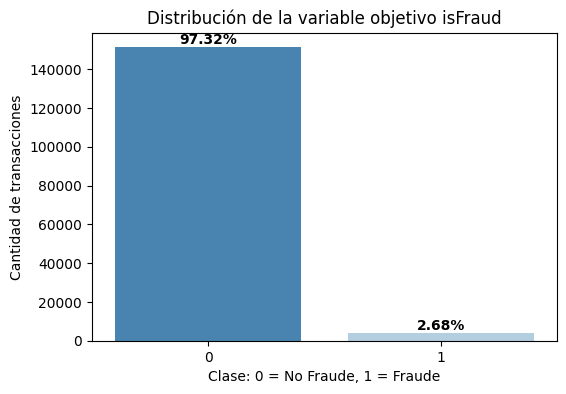

In [4]:
# Distribución de la variable objetivo
target_counts = df['isFraud'].value_counts()
target_percent = df['isFraud'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Clase': ['No Fraude', 'Fraude'],
    'Cantidad': [target_counts[0], target_counts[1]],
    'Porcentaje': [target_percent[0], target_percent[1]]
})

display(target_summary)

plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='isFraud', palette='Blues_r')

for p in ax.patches:
    porcentaje = 100 * p.get_height() / len(df)
    ax.annotate(f'{porcentaje:.2f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold')

plt.title('Distribución de la variable objetivo isFraud')
plt.xlabel('Clase: 0 = No Fraude, 1 = Fraude')
plt.ylabel('Cantidad de transacciones')
plt.show()


La variable objetivo presenta un fuerte desbalance de clases. La mayoría de las transacciones corresponden a operaciones legítimas (No Fraude), mientras que los casos fraudulentos representan una proporción significativamente menor del conjunto de datos. Esta distribución es característica de los problemas reales de detección de fraude y deberá ser considerada en las etapas posteriores de análisis y modelado.


In [6]:
# Número de registros y variables
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 155504
Número de variables: 434


In [7]:
# Tipos de datos
print("\nTipos de datos por variable:")
print(df.dtypes.value_counts())


Tipos de datos por variable:
float64    399
object      31
int64        4
Name: count, dtype: int64


## Diagnostico de Calidad de datos

,variable,porcentaje_faltantes
0,id_24,98.608396
1,id_25,98.506791
2,id_21,98.501646
3,id_07,98.499717
4,id_26,98.499717
5,id_08,98.499717
6,id_23,98.499074
7,id_27,98.499074
8,id_22,98.499074
9,D7,93.389238


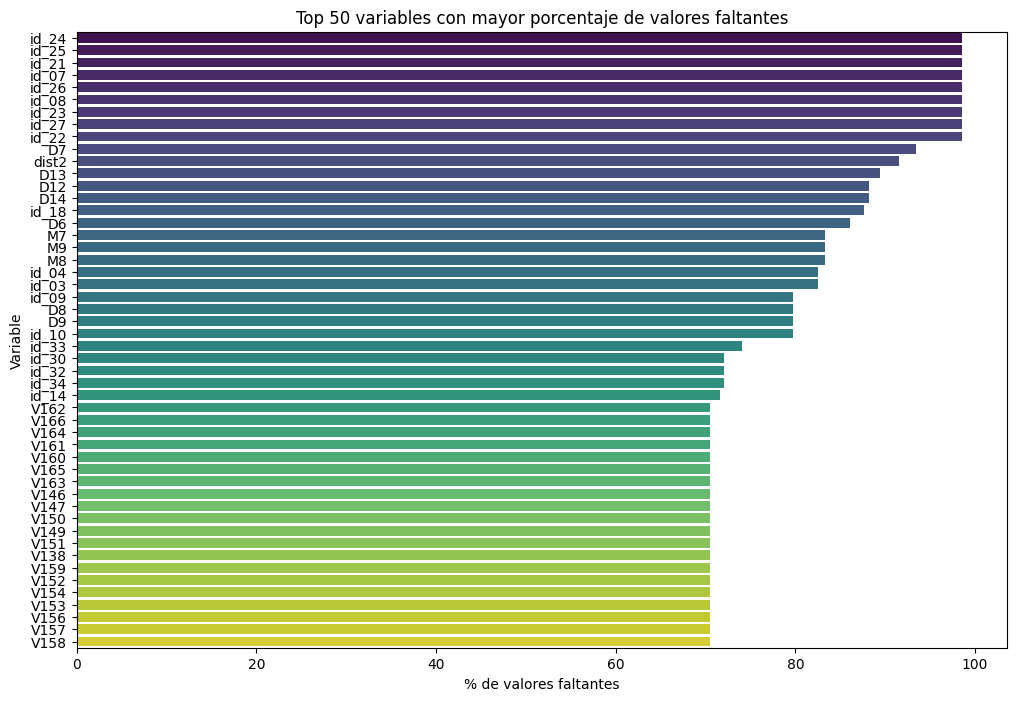

In [8]:
# Porcentaje de valores faltantes por variable
missing_percent = df.isnull().mean().sort_values(ascending=False) * 100

missing_df = pd.DataFrame({'variable': missing_percent.index,'porcentaje_faltantes': missing_percent.values})

display(missing_df.head(50))

plt.figure(figsize=(12,8))
sns.barplot(data=missing_df.head(50),x='porcentaje_faltantes',y='variable',palette='viridis')
plt.title('Top 50 variables con mayor porcentaje de valores faltantes')
plt.xlabel('% de valores faltantes')
plt.ylabel('Variable')
plt.show()

Verificación de variables numéricas con la variable objetivo, con el fin de identificar cuales variables se pueden descartar de nuestro estudio antes de realizar su respectivo análisis

In [9]:
# Correlación de variables numéricas con isFraud
numeric_df = df.select_dtypes(include=np.number)

corr_fraud = numeric_df.corr()['isFraud'].sort_values(ascending=False)

corr_fraud_df = pd.DataFrame({
    'variable': corr_fraud.index,
    'correlacion_isFraud': corr_fraud.values
})

# Unir porcentaje de faltantes con correlación
decision_df = missing_df.merge(corr_fraud_df, on='variable', how='left')

# Regla de decisión
decision_df['accion'] = np.where(
    (decision_df['porcentaje_faltantes'] > 50) &
    (decision_df['correlacion_isFraud'].abs() < 0.05),
    'Eliminar',
    'Conservar o evaluar'
)

display(decision_df.head(80))

,variable,porcentaje_faltantes,correlacion_isFraud,accion
0,id_24,98.608396,-0.039057,Eliminar
1,id_25,98.506791,-0.022620,Eliminar
2,id_21,98.501646,0.053618,Conservar o evaluar
3,id_07,98.499717,-0.030171,Eliminar
4,id_26,98.499717,0.042264,Eliminar
...,...,...,...,...
75,V338,70.417481,0.007676,Eliminar
76,V336,70.417481,0.018776,Eliminar
77,V1,68.979576,0.001325,Eliminar
78,D11,68.979576,-0.041673,Eliminar


In [10]:
corr_fraud = (numeric_df.corr()['isFraud'].drop('isFraud'))

In [11]:
corr_fraud.abs().sort_values(ascending=False).head(30)

,isFraud
V201,0.347312
V257,0.325970
V200,0.318928
V189,0.311797
V45,0.297216
V246,0.292376
V188,0.279441
V244,0.263798
V233,0.256858
V44,0.256090


### **¿Cuáles de las variables más correlacionadas tienen más del 70% de faltantes?**

In [12]:
top_corr = corr_fraud.abs().sort_values(ascending=False).head(30)

for var in top_corr.index:
    print(f"{var:10} | Corr={corr_fraud[var]:.3f} | Missing={missing_percent[var]:.2f}%")

V201       | Corr=0.347 | Missing=61.21%
V257       | Corr=0.326 | Missing=62.60%
V200       | Corr=0.319 | Missing=61.21%
V189       | Corr=0.312 | Missing=61.21%
V45        | Corr=0.297 | Missing=43.09%
V246       | Corr=0.292 | Missing=62.60%
V188       | Corr=0.279 | Missing=61.21%
V244       | Corr=0.264 | Missing=62.60%
V233       | Corr=0.257 | Missing=62.60%
V44        | Corr=0.256 | Missing=43.09%
V242       | Corr=0.247 | Missing=62.60%
V87        | Corr=0.234 | Missing=30.25%
V171       | Corr=0.233 | Missing=61.21%
V156       | Corr=0.224 | Missing=70.52%
V86        | Corr=0.217 | Missing=30.25%
V149       | Corr=0.214 | Missing=70.52%
V231       | Corr=0.214 | Missing=62.60%
V52        | Corr=0.207 | Missing=43.09%
V232       | Corr=0.205 | Missing=62.60%
V158       | Corr=0.204 | Missing=70.52%
id_22      | Corr=0.194 | Missing=98.50%
V228       | Corr=0.186 | Missing=62.60%
V198       | Corr=0.185 | Missing=61.21%
V51        | Corr=0.183 | Missing=43.09%
V155       | Cor

### **Clasificación de variables según relevancia**

In [13]:
top_corr = corr_fraud.abs().sort_values(ascending=False).head(30)

top_variables = pd.DataFrame({
    'Variable': top_corr.index,
    'Correlacion': top_corr.values,
    'Missing (%)': [missing_percent[var] for var in top_corr.index]
})

display(top_variables)

,Variable,Correlacion,Missing (%)
0,V201,0.347312,61.206786
1,V257,0.325970,62.595817
2,V200,0.318928,61.206786
3,V189,0.311797,61.206786
4,V45,0.297216,43.090210
5,V246,0.292376,62.595817
6,V188,0.279441,61.206786
7,V244,0.263798,62.595817
8,V233,0.256858,62.595817
9,V44,0.256090,43.090210


El análisis de correlación evidenció que varias variables presentan una relación significativa con la ocurrencia de fraude financiero. Se identificaron variables como id_22, V201, V189, V200 y V257 con coeficientes de correlación superiores a 0.29 respecto a la variable objetivo. Aunque algunas de estas variables presentan porcentajes elevados de valores faltantes, su capacidad explicativa sugiere que no deben ser eliminadas automáticamente. Por esta razón, la decisión de conservación o eliminación de variables se fundamentó en una evaluación conjunta del porcentaje de datos faltantes y su relación con el fraude.

In [14]:
# Número de registros y variables
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 155504
Número de variables: 434


In [15]:
cols_eliminar = decision_df[
    (decision_df['porcentaje_faltantes'] > 50) &
    (decision_df['correlacion_isFraud'].abs() < 0.05)
]['variable'].tolist()

len(cols_eliminar)

127

Luego la verificación sobre columnas con cantidad de datos faltantes mayor al 50% y poca correlación con nuestra variable objetivo, se proceden a eliminar antes del análisis exploratorio

In [16]:
df_clean = df.drop(columns=cols_eliminar)

print("Dimensiones originales:", df.shape)
print("Dimensiones después de limpieza:", df_clean.shape)

Dimensiones originales: (155504, 434)
Dimensiones después de limpieza: (155504, 307)


# 1. Imputación de valores nulos y transformación

Después de eliminar las variables con alto porcentaje de ausencia y baja relación con isFraud, se procedió al tratamiento de los valores faltantes restantes. Para evitar pérdida adicional de información, se conservaron las variables relevantes y se aplicaron estrategias diferenciadas según el tipo de dato.

En las variables numéricas se utilizó la mediana, debido a que es una medida robusta ante valores extremos, especialmente importante en un problema de fraude financiero. En las variables categóricas se imputó la categoría "Unknown", con el fin de conservar la ausencia como una posible señal informativa. Además, se crearon indicadores binarios para marcar qué registros tenían valores faltantes originalmente.

In [17]:
import numpy as np
import pandas as pd

from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

print("---- INICIO DEL PIPELINE DE IMPUTACIÓN Y TRANSFORMACIÓN ----")

# Se parte del dataset previamente depurado
df_imputed = df_clean.copy()

print("Dimensiones antes de imputar:", df_imputed.shape)
print("Valores nulos antes de imputar:", df_imputed.isnull().sum().sum())

# ============================================================
# FASE 1. CREACIÓN DE INDICADORES DE AUSENCIA
# ============================================================

# Identificar columnas con valores faltantes
cols_con_nulos = df_imputed.columns[
    df_imputed.isnull().sum() > 0
]

print("Variables con valores faltantes:", len(cols_con_nulos))

# Crear una variable indicadora por cada columna con valores faltantes
for col in cols_con_nulos:
    df_imputed[f'{col}_was_null'] = df_imputed[col].isnull().astype(int)

print("Indicadores de ausencia creados:", len(cols_con_nulos))
print("Dimensiones después de crear indicadores:", df_imputed.shape)

# ============================================================
# FASE 2. SELECCIÓN DE VARIABLES PARA IMPUTACIÓN KNN
# ============================================================

# Variables del bloque C
cols_C = [col for col in df_imputed.columns
    if col.startswith('C') and df_imputed[col].dtype != 'object'
]

# Variables del bloque D
cols_D = [col for col in df_imputed.columns
    if col.startswith('D') and df_imputed[col].dtype != 'object'
]

# Se incluye TransactionAmt por contexto del negocio
cols_knn = ['TransactionAmt'] + cols_C + cols_D

# Conservar únicamente columnas existentes, numéricas y con al menos un valor faltante
cols_knn = [
    col for col in cols_knn
    if col in df_imputed.columns
    and pd.api.types.is_numeric_dtype(df_imputed[col])
    and df_imputed[col].isnull().sum() > 0
]

print("Variables seleccionadas para imputación KNN:")
print(cols_knn)
print("Cantidad de variables imputadas con KNN:", len(cols_knn))

# ============================================================
# FASE 3. IMPUTACIÓN MULTIVARIADA MEDIANTE KNN
# ============================================================

if len(cols_knn) > 0:

    # Escalamiento
    scaler_knn = MinMaxScaler()

    data_knn = df_imputed[cols_knn].copy()
    data_knn_scaled = scaler_knn.fit_transform(data_knn)

    # Imputación KNN
    knn_imputer = KNNImputer(
        n_neighbors=5,
        weights='distance'
    )

    data_knn_imputed_scaled = knn_imputer.fit_transform(data_knn_scaled)

    # Retornar a escala original
    data_knn_imputed = scaler_knn.inverse_transform(
        data_knn_imputed_scaled
    )

    # Reemplazar en el dataset
    df_imputed[cols_knn] = data_knn_imputed

    print("Imputación KNN finalizada correctamente.")

else:
    print("No se encontraron variables numéricas con nulos para KNN.")

# ============================================================
# FASE 4. IMPUTACIÓN NUMÉRICA RESTANTE CON MEDIANA
# ============================================================

num_cols = df_imputed.select_dtypes(include=np.number).columns

cols_num_restantes = []

for col in num_cols:
    if col != 'isFraud' and df_imputed[col].isnull().sum() > 0:
        cols_num_restantes.append(col)
        df_imputed[col] = df_imputed[col].fillna(
            df_imputed[col].median()
        )

print("Variables numéricas imputadas con mediana:", len(cols_num_restantes))
print(cols_num_restantes[:30])


# ============================================================
# FASE 5. IMPUTACIÓN CATEGÓRICA CON UNKNOWN
# ============================================================

cat_cols = df_imputed.select_dtypes(exclude=np.number).columns

cols_cat_imputadas = []

for col in cat_cols:
    if df_imputed[col].isnull().sum() > 0:
        cols_cat_imputadas.append(col)
        df_imputed[col] = df_imputed[col].fillna('Unknown')

print("Variables categóricas imputadas con Unknown:", len(cols_cat_imputadas))
print(cols_cat_imputadas)


# ============================================================
# FASE 6. TRANSFORMACIÓN DE TransactionAmt
# ============================================================

scaler_transaction = StandardScaler()

df_imputed['TransactionAmt_scaled'] = scaler_transaction.fit_transform(
    df_imputed[['TransactionAmt']]
)

print("Variable TransactionAmt_scaled creada correctamente.")


# ============================================================
# FASE 7. AUDITORÍA FINAL DE INTEGRIDAD
# ============================================================

total_nulos_final = df_imputed.isnull().sum().sum()

print("Dimensiones finales:", df_imputed.shape)
print("Total de valores nulos finales:", total_nulos_final)

missing_final = (
    df_imputed
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing_final.head(20))

if total_nulos_final == 0:
    print("El dataset imputado no presenta valores nulos.")
else:
    print("Aún existen valores nulos por revisar.")




---- INICIO DEL PIPELINE DE IMPUTACIÓN Y TRANSFORMACIÓN ----
Dimensiones antes de imputar: (155504, 307)
Valores nulos antes de imputar: 15374944
Variables con valores faltantes: 243
Indicadores de ausencia creados: 243
Dimensiones después de crear indicadores: (155504, 550)
Variables seleccionadas para imputación KNN:
['D2', 'D4', 'D5', 'D7', 'D8', 'D9', 'D10', 'D15']
Cantidad de variables imputadas con KNN: 8
Imputación KNN finalizada correctamente.
Variables numéricas imputadas con mediana: 205
['card2', 'card3', 'card5', 'addr1', 'addr2', 'V3', 'V7', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32']
Variables categóricas imputadas con Unknown: 30
['card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37

,0
TransactionAmt_scaled,0
TransactionID,0
isFraud,0
TransactionDT,0
TransactionAmt,0
ProductCD,0
card1,0
id_22_was_null,0
id_21_was_null,0
id_19_was_null,0


El dataset imputado no presenta valores nulos.


# 2. Detección de atípicos

In [21]:
corr_fraude = df_clean.corr(numeric_only=True)['isFraud'].abs()

top20_corr = corr_fraude.sort_values(ascending=False).drop('isFraud')


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

print("--- DIAGNÓSTICO COMPARATIVO DE VALORES ATÍPICOS ---")

# Subconjunto usado en la metodología
vars_atipicos = ['TransactionAmt', 'C1', 'isFraud']

df_atipicos = df_clean[vars_atipicos].dropna().copy()

X = df_atipicos[['TransactionAmt', 'C1']]
y = df_atipicos['isFraud']

print("Registros evaluados:", len(df_atipicos))

# =========================
# 1. Método IQR
# =========================

Q1 = df_atipicos['TransactionAmt'].quantile(0.25)
Q3 = df_atipicos['TransactionAmt'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

df_atipicos['IQR'] = np.where(df_atipicos['TransactionAmt'] > limite_superior, 'Atípico', 'Normal')

# =========================
# 2. Isolation Forest
# =========================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(contamination=0.03, random_state=42)

df_atipicos['Isolation Forest'] = np.where(iso.fit_predict(X_scaled) == -1, 'Atípico','Normal')

# =========================
# 3. k-NN basado en distancia
# =========================

knn = NearestNeighbors(n_neighbors=5)

knn.fit(X_scaled)

distancias, indices = knn.kneighbors(X_scaled)

df_atipicos['knn_score'] = distancias.mean(axis=1)

umbral_knn = df_atipicos['knn_score'].quantile(0.97)

df_atipicos['k-NN'] = np.where(df_atipicos['knn_score'] > umbral_knn, 'Atípico', 'Normal')

# =========================
# 4. Resumen comparativo
# =========================

metodos = ['IQR', 'Isolation Forest', 'k-NN']

resumen = []

for metodo in metodos:
    df_temp = df_atipicos[df_atipicos[metodo] == 'Atípico']

    total_atipicos = len(df_temp)
    fraudes_detectados = df_temp['isFraud'].sum()
    porcentaje_fraude = df_temp['isFraud'].mean() * 100 if total_atipicos > 0 else 0

    resumen.append({
        'Método': metodo,
        'Atípicos detectados': total_atipicos,
        'Fraudes dentro de atípicos': int(fraudes_detectados),
        '% Fraude dentro de atípicos': porcentaje_fraude
    })

resumen_atipicos = pd.DataFrame(resumen)

display(resumen_atipicos.round(2))

--- DIAGNÓSTICO COMPARATIVO DE VALORES ATÍPICOS ---
Registros evaluados: 155504


,Método,Atípicos detectados,Fraudes dentro de atípicos,% Fraude dentro de atípicos
0,IQR,15184,578,3.81
1,Isolation Forest,4665,287,6.15
2,k-NN,4666,340,7.29


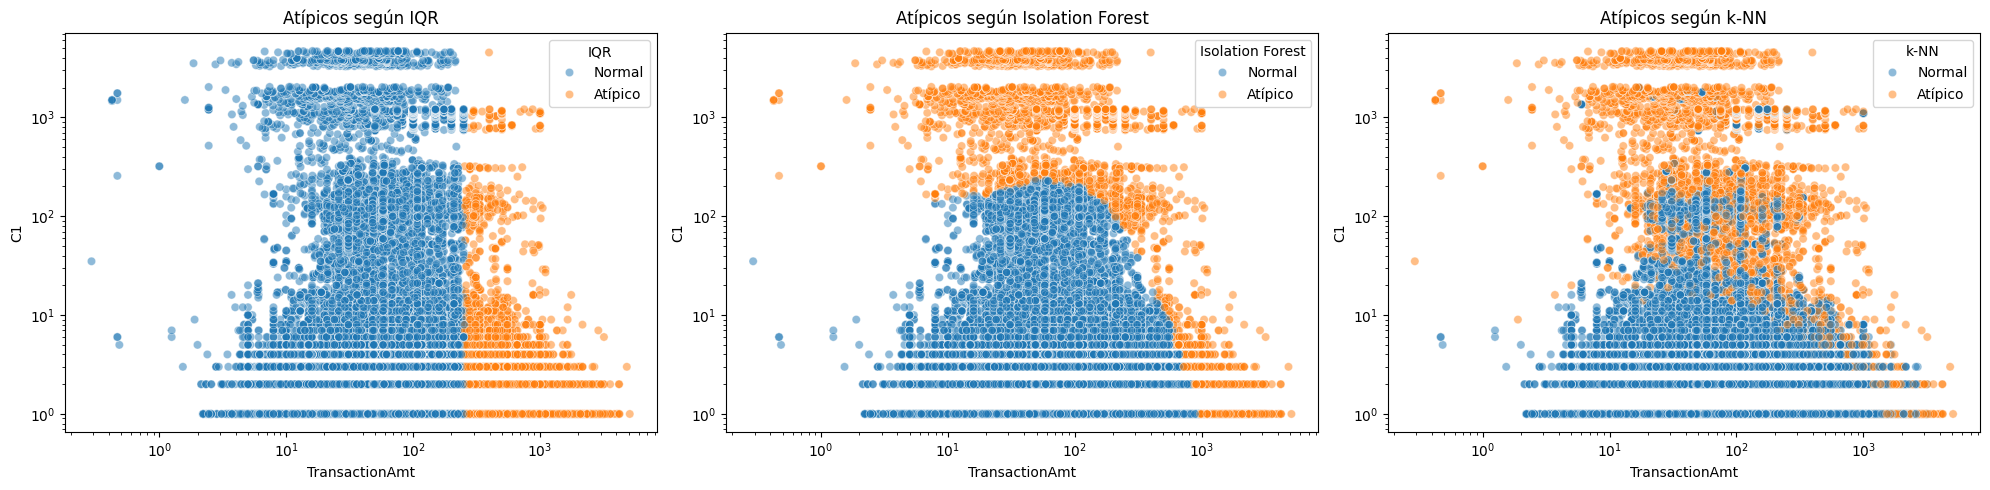

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, metodo in zip(axes, metodos):
    sns.scatterplot(data=df_atipicos, x='TransactionAmt', y='C1', hue=metodo, alpha=0.5, ax=ax
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'Atípicos según {metodo}')
    ax.set_xlabel('TransactionAmt')
    ax.set_ylabel('C1')

plt.tight_layout()
plt.show()

# 2. Análisis exploratorio de datos (EDA)

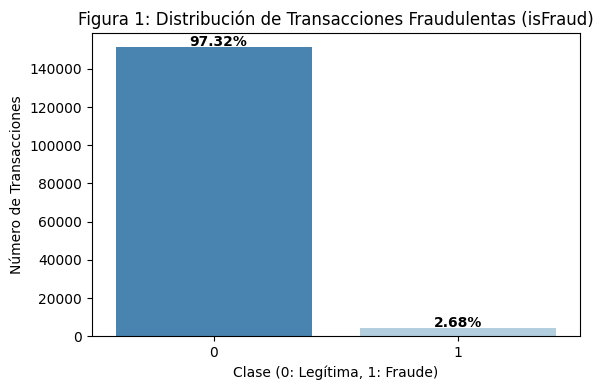

isFraud
0    151332
1      4172
Name: count, dtype: int64


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización de la distribución de la variable objetivo
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='isFraud', data=df, palette='Blues_r')
plt.title('Figura 1: Distribución de Transacciones Fraudulentas (isFraud)', fontsize=12)
plt.xlabel('Clase (0: Legítima, 1: Fraude)')
plt.ylabel('Número de Transacciones')

# Inclusión de etiquetas de porcentaje
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + (total * 0.005)
    ax.annotate(percentage, (x, y), fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('figura1_desbalance.png', dpi=300)
plt.show()

print(df['isFraud'].value_counts())

## 2.1. Análisis univariado

### Análisis Univariado de `TransactionDT`

Vamos a realizar un análisis univariado de la variable `TransactionDT` para entender su distribución temporal. Esto nos permitirá identificar patrones, picos o anomalías en el tiempo de las transacciones.

In [26]:
from scipy.stats import skew, kurtosis

# Extracción de la variable temporal
muestra_dt = df_clean['TransactionDT']

# Cálculo de estadísticos descriptivos y de forma
media_dt = np.mean(muestra_dt)
desviacion_estandar_dt = np.std(muestra_dt)
asimetria_dt = skew(muestra_dt)
curtosis_dt = kurtosis(muestra_dt, fisher=True)

print(f"Media de TransactionDT: {media_dt:.2f}")
print(f"Desviación Estándar de TransactionDT: {desviacion_estandar_dt:.2f}")
print(f"Asimetría de TransactionDT: {asimetria_dt:.2f}")
print(f"Curtosis de TransactionDT: {curtosis_dt:.2f}")

Media de TransactionDT: 1645176.74
Desviación Estándar de TransactionDT: 853422.15
Asimetría de TransactionDT: -0.03
Curtosis de TransactionDT: -0.99


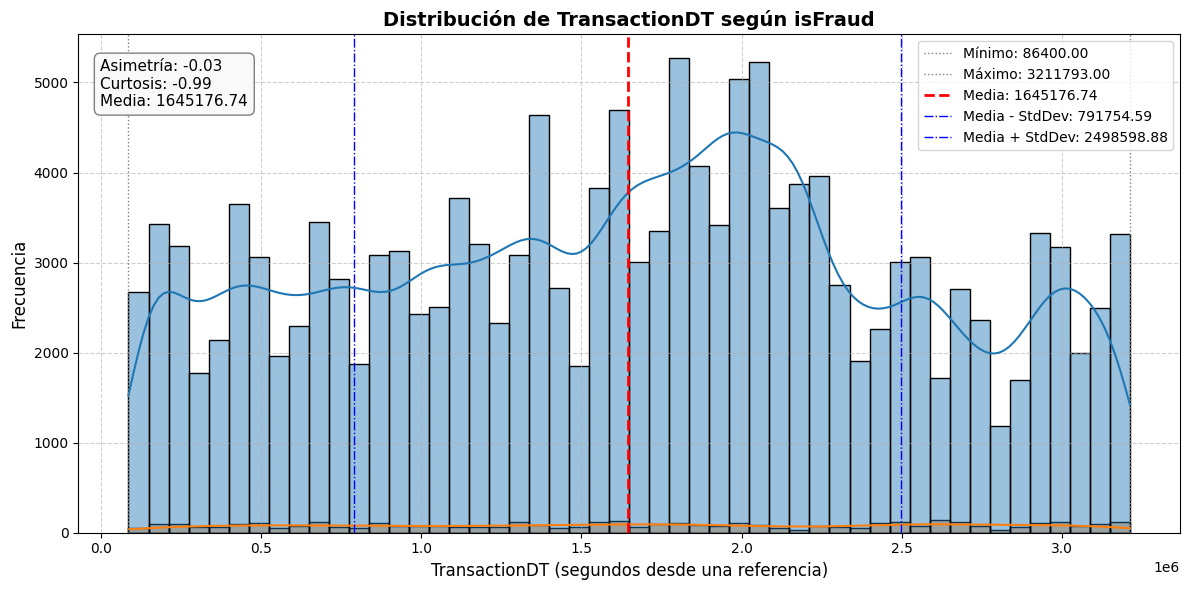

In [28]:
# Variable temporal desde el dataset limpio
muestra_dt = df_clean['TransactionDT']

# Estadísticos
media_dt = np.mean(muestra_dt)
desviacion_estandar_dt = np.std(muestra_dt)
asimetria_dt = skew(muestra_dt)
curtosis_dt = kurtosis(muestra_dt, fisher=True)

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df_clean,
    x='TransactionDT',
    hue='isFraud',
    bins=50,
    kde=True,
    multiple='layer',
    alpha=0.45
)

plt.axvline(np.min(muestra_dt), color='gray', linestyle=':', linewidth=1, label=f'Mínimo: {np.min(muestra_dt):.2f}')
plt.axvline(np.max(muestra_dt), color='gray', linestyle=':', linewidth=1, label=f'Máximo: {np.max(muestra_dt):.2f}')
plt.axvline(media_dt, color='red', linestyle='--', linewidth=2, label=f'Media: {media_dt:.2f}')

plt.axvline(media_dt - desviacion_estandar_dt, color='blue', linestyle='-.', linewidth=1, label=f'Media - StdDev: {(media_dt - desviacion_estandar_dt):.2f}')
plt.axvline(media_dt + desviacion_estandar_dt, color='blue', linestyle='-.', linewidth=1, label=f'Media + StdDev: {(media_dt + desviacion_estandar_dt):.2f}')

plt.title("Distribución de TransactionDT según isFraud", fontsize=14, fontweight='bold')
plt.xlabel("TransactionDT (segundos desde una referencia)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)

plt.text(
    0.02, 0.95,
    f"Asimetría: {asimetria_dt:.2f}\nCurtosis: {curtosis_dt:.2f}\nMedia: {media_dt:.2f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#f9f9f9", edgecolor="gray")
)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

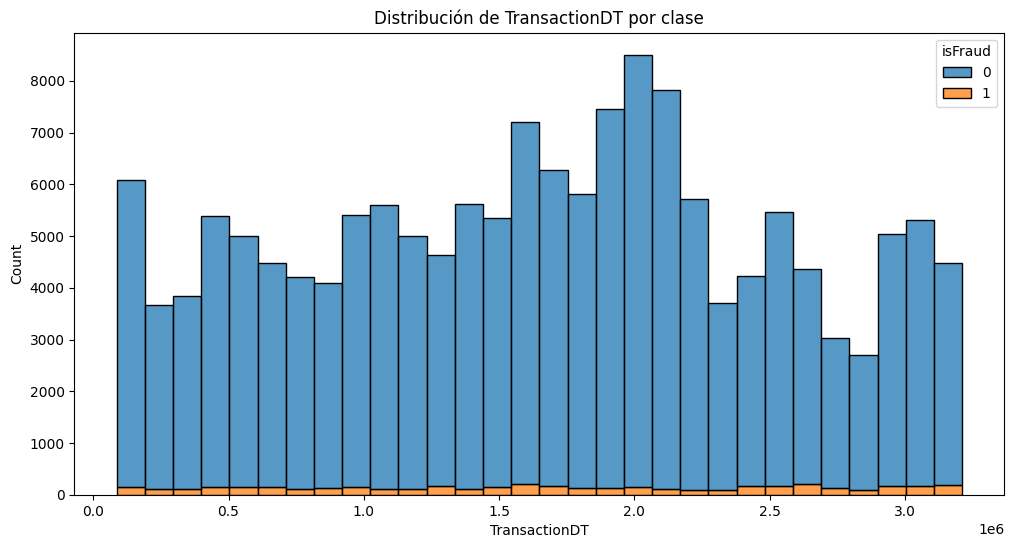

In [29]:
plt.figure(figsize=(12,6))

sns.histplot(data=df_clean,x='TransactionDT',hue='isFraud',bins=30,multiple='stack')

plt.title('Distribución de TransactionDT por clase')
plt.show()

In [30]:
df_clean['DT_bin'] = pd.qcut(df_clean['TransactionDT'],q=10,duplicates='drop')

tabla_dt = pd.crosstab(df_clean['DT_bin'],df_clean['isFraud'], normalize='index') * 100

tabla_dt

isFraud,0,1
DT_bin,,
"(86399.999, 424434.0]",97.279918,2.720082
"(424434.0, 771233.8]",97.009646,2.990354
"(771233.8, 1112601.1]",97.382637,2.617363
"(1112601.1, 1404011.4]",97.556427,2.443573
"(1404011.4, 1703424.0]",97.401929,2.598071
"(1703424.0, 1929211.0]",97.710611,2.289389
"(1929211.0, 2146273.4]",98.328082,1.671918
"(2146273.4, 2468198.8]",97.832797,2.167203
"(2468198.8, 2856452.5]",96.276527,3.723473


###Análisis Univariado de `TransactionAmt`

In [33]:
from scipy.stats import skew, kurtosis

muestra_dt = df_clean['TransactionAmt']

media_dt = np.mean(muestra_dt)
desviacion_estandar_dt = np.std(muestra_dt)
asimetria_dt = skew(muestra_dt)
curtosis_dt = kurtosis(muestra_dt, fisher=True)

print(f"Media de TransactionAmt: {media_dt:.2f}")
print(f"Desviación Estándar de TransactionAmt: {desviacion_estandar_dt:.2f}")
print(f"Asimetría de TransactionAmt: {asimetria_dt:.2f}")
print(f"Curtosis de TransactionAmt: {curtosis_dt:.2f}")

Media de TransactionAmt: 128.34
Desviación Estándar de TransactionAmt: 200.94
Asimetría de TransactionAmt: 6.78
Curtosis de TransactionAmt: 70.78


In [35]:
df_clean['Amt_bin'] = pd.qcut(df_clean['TransactionAmt'], q=10,duplicates='drop')

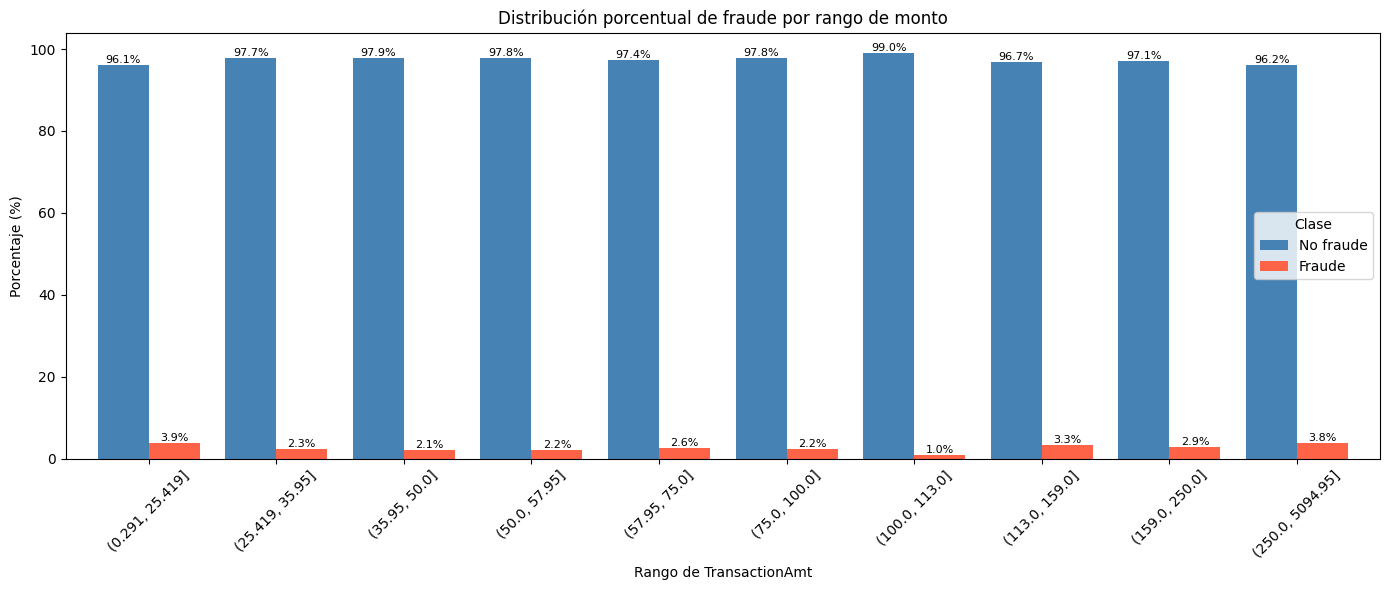

In [36]:
tabla_amt = (
    pd.crosstab(
        df_clean['Amt_bin'],
        df_clean['isFraud'],
        normalize='index'
    ) * 100
)

tabla_amt.columns = ['No fraude', 'Fraude']

ax = tabla_amt.plot(
    kind='bar',
    figsize=(14,6),
    width=0.8,
    color=['steelblue','tomato']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)

plt.title('Distribución porcentual de fraude por rango de monto')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Rango de TransactionAmt')
plt.xticks(rotation=45)
plt.legend(title='Clase')
plt.tight_layout()
plt.show()

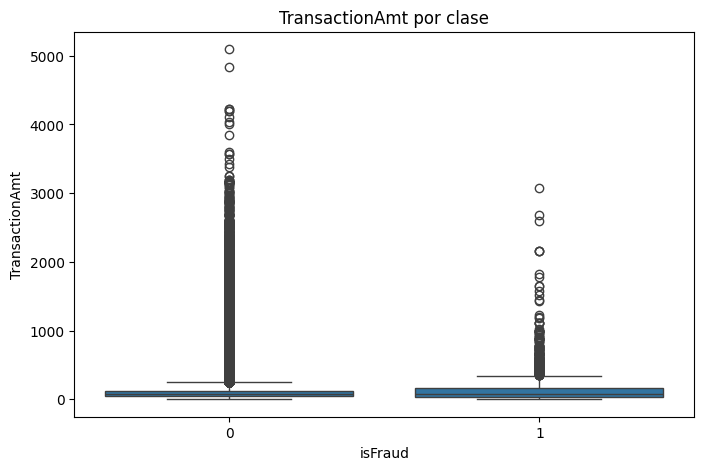

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_clean, x='isFraud', y='TransactionAmt')

plt.title('TransactionAmt por clase')
plt.show()

## 2.2. Análisis bivariado

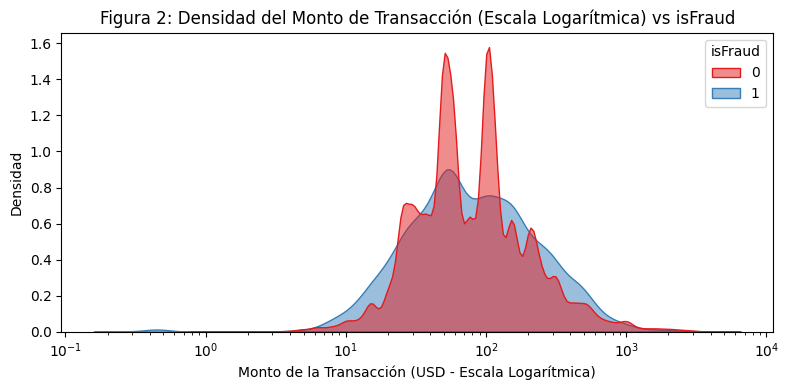

In [38]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='TransactionAmt', hue='isFraud', fill=True, common_norm=False, palette='Set1', log_scale=True, alpha=0.5)
plt.title('Figura 2: Densidad del Monto de Transacción (Escala Logarítmica) vs isFraud', fontsize=12)
plt.xlabel('Monto de la Transacción (USD - Escala Logarítmica)')
plt.ylabel('Densidad')
plt.tight_layout()
#plt.savefig('figura2_monto_density.png', dpi=300)
plt.show()

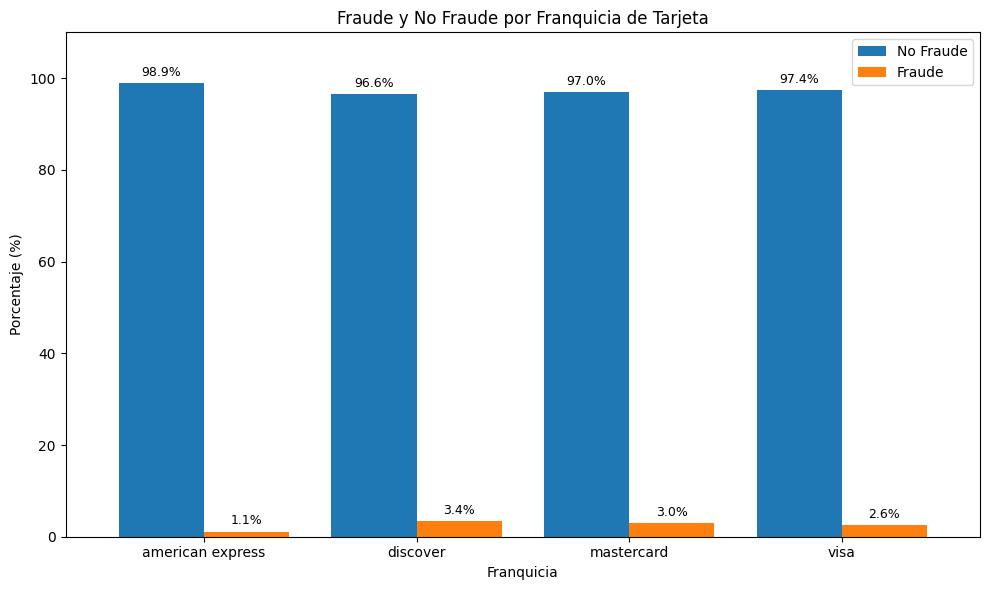

In [44]:
# Porcentaje de fraude y no fraude por franquicia

tabla_card = (pd.crosstab(df_clean['card4'], df_clean['isFraud'], normalize='index') * 100)

ax = tabla_card.plot(kind='bar', figsize=(10,6),width=0.8)

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%', fontsize=9, padding=3)

plt.title('Fraude y No Fraude por Franquicia de Tarjeta')
plt.xlabel('Franquicia')
plt.ylabel('Porcentaje (%)')
plt.legend(['No Fraude', 'Fraude'])

plt.xticks(rotation=0)
plt.ylim(0, 110)

plt.tight_layout()
plt.show()

'MasterCard' (3.1%%) y 'Discover' (3.0%%) presentan proporciones de fraude ligeramente superiores en comparación con 'Visa' (2.51%) y 'American Express' (1.4%). Estas diferencias, aunque menores, podrían indicar variaciones en los métodos de seguridad o el perfil de riesgo asociado a cada franquicia.

In [45]:
tabla_device = (pd.crosstab(df_clean['DeviceType'], df_clean['isFraud'], normalize='index') * 100)

display(tabla_device.round(2))

isFraud,0,1
DeviceType,,
desktop,97.01,2.99
mobile,94.55,5.45


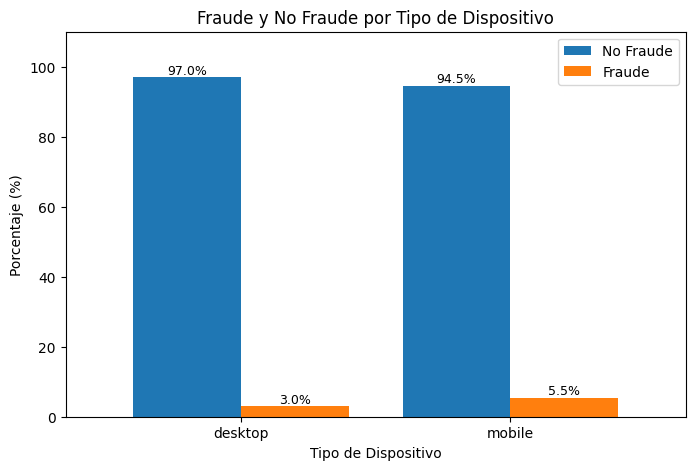

In [46]:
ax = tabla_device.plot(kind='bar', figsize=(8,5), width=0.8)

for container in ax.containers:ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.title('Fraude y No Fraude por Tipo de Dispositivo')
plt.xlabel('Tipo de Dispositivo')
plt.ylabel('Porcentaje (%)')
plt.legend(['No Fraude', 'Fraude'])

plt.xticks(rotation=0)
plt.ylim(0,110)

plt.show()



El gráfico de barras para la tasa de fraude por `DeviceType` revela
que los dispositivos móviles (`Mobile`) presentan una tasa de fraude considerablemente más alta que los dispositivos `Desktop`. Esto podría deberse a varios factores, como una menor seguridad en dispositivos móviles, la facilidad para realizar transacciones rápidas que pueden ser explotadas por estafadores, o patrones de uso que favorecen el fraude.



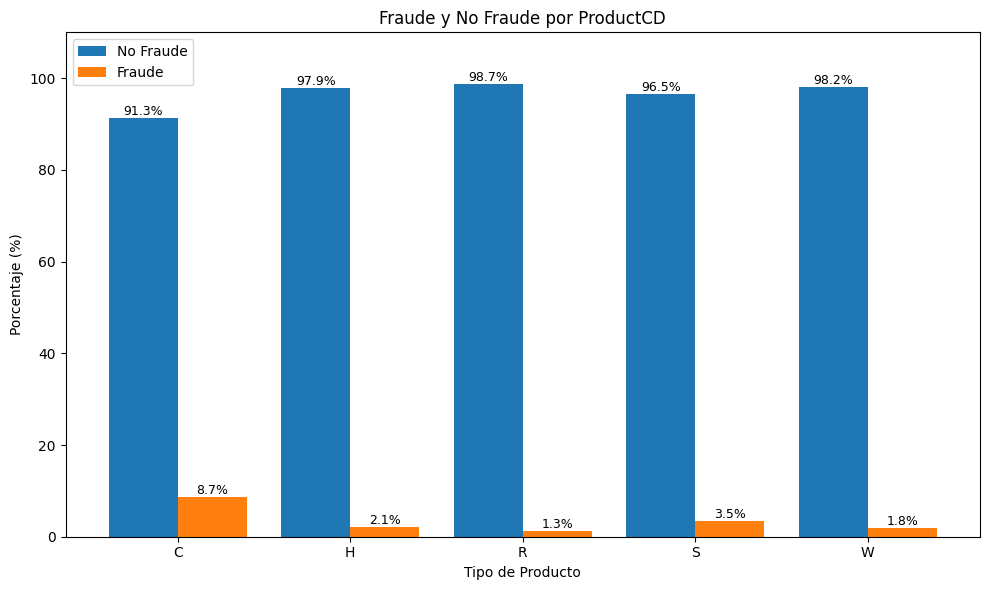

In [47]:
tabla_prod = (pd.crosstab(df_clean['ProductCD'], df_clean['isFraud'], normalize='index') * 100)

ax = tabla_prod.plot(kind='bar', figsize=(10,6),width=0.8)

for container in ax.containers: ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.title('Fraude y No Fraude por ProductCD')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Tipo de Producto')

plt.legend(['No Fraude','Fraude'])

plt.xticks(rotation=0)
plt.ylim(0,110)

plt.tight_layout()
plt.show()

In [43]:
tabla_card = (pd.crosstab(df_clean['ProductCD'],df_clean['isFraud'], normalize='index') * 100
)
display(tabla_card.round(2))

isFraud,0,1
ProductCD,,
C,91.29,8.71
H,97.89,2.11
R,98.70,1.30
S,96.51,3.49
W,98.17,1.83


Se observa una clara predominancia del fraude en ciertas categorías de productos. Por ejemplo, los códigos 'S' y 'C' muestran una cantidad significativa de transacciones fraudulentas, siendo la categoría 'C' particularmente crítica ya que un alto porcentaje de sus transacciones son fraude, indicando que el tipo de producto puede ser un factor discriminante fuerte.

In [48]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Preparación de datos para la prueba de independencia
df_chi = df[['DeviceType', 'isFraud']].dropna()

print(f"Registros evaluados para la prueba: {len(df_chi)}")

# 1. Generación de la tabla de contingencia
tabla_contingencia = pd.crosstab(df_chi['DeviceType'], df_chi['isFraud'])
print("\n--- TABLA DE CONTINGENCIA ---")
print(tabla_contingencia)

# 2. Ejecución de la prueba Chi-cuadrado
chi2, p, dof, esperados = chi2_contingency(tabla_contingencia)

# 3. Cálculo de la V de Cramer para medir el tamaño del efecto
n = tabla_contingencia.sum().sum()
min_dimension = min(tabla_contingencia.shape) - 1
v_cramer = np.sqrt(chi2 / (n * min_dimension))

print("\n--- RESULTADOS ESTADÍSTICOS ---")
print(f"Estadístico Chi-cuadrado (χ²): {chi2:.4f}")
print(f"P-valor: {p:.4e}")
print(f"V de Cramer: {v_cramer:.4f}")

# Interpretación de resultados
alpha = 0.05
if p < alpha:
    print("\nConclusión: Se rechaza H0. Existe una relación significativa entre el Tipo de Dispositivo y el Fraude.")
else:
    print("\nConclusión: No se rechaza H0. No hay evidencia de relación estadística.")

Registros evaluados para la prueba: 61044

--- TABLA DE CONTINGENCIA ---
isFraud         0     1
DeviceType             
desktop     37782  1165
mobile      20892  1205

--- RESULTADOS ESTADÍSTICOS ---
Estadístico Chi-cuadrado (χ²): 228.3362
P-valor: 1.3747e-51
V de Cramer: 0.0612

Conclusión: Se rechaza H0. Existe una relación significativa entre el Tipo de Dispositivo y el Fraude.


Se aplicó una prueba Chi-cuadrado de independencia para evaluar si el tipo de dispositivo está asociado con la ocurrencia de fraude. El p-valor obtenido fue extremadamente bajo, por lo que se rechaza la hipótesis nula y se concluye que existe una relación estadísticamente significativa entre DeviceType y isFraud.

## 2.3. Análisis multivariado

In [49]:
numeric_cols = df_clean.select_dtypes(include=np.number)

corr_spearman = (numeric_cols.corr(method='spearman')['isFraud'].drop('isFraud'))

corr_spearman = corr_spearman.sort_values(key=abs, ascending=False)

top15 = corr_spearman.head(15)

display(top15)

,isFraud
V244,0.340103
V242,0.314055
V246,0.311993
V243,0.309369
V258,0.286120
V257,0.285168
V190,0.264492
V186,0.251073
V232,0.248147
V233,0.243824


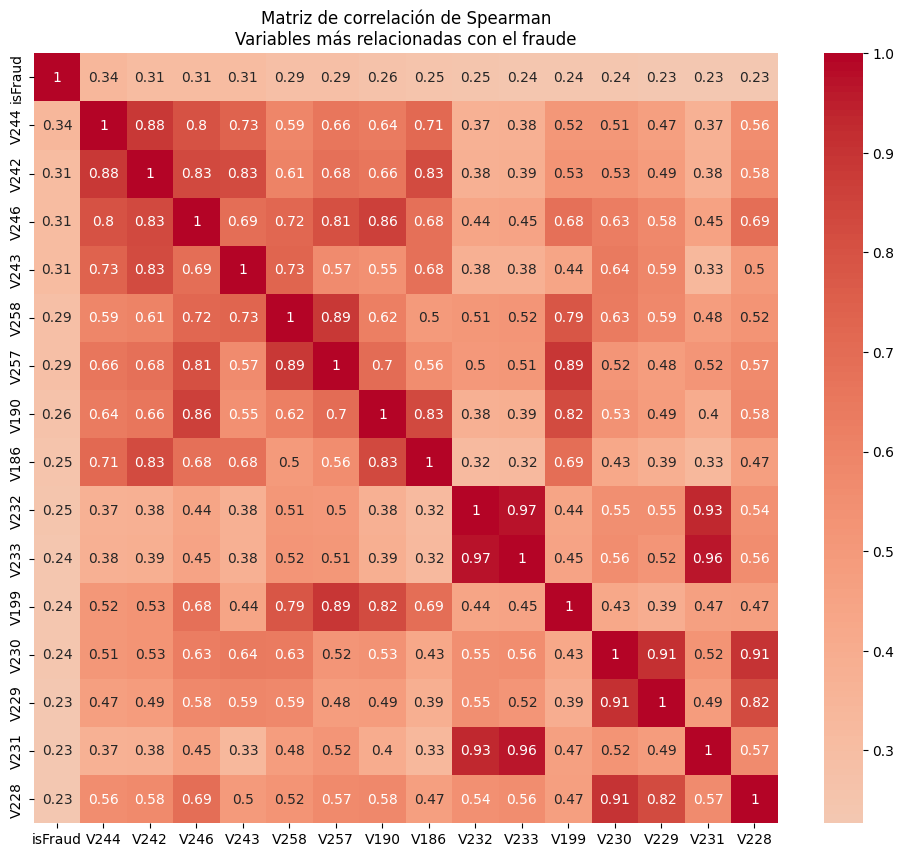

In [50]:
variables_heatmap = ['isFraud'] + list(top15.index)

plt.figure(figsize=(12,10))

sns.heatmap(df_clean[variables_heatmap].corr(method='spearman') ,annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de correlación de Spearman\nVariables más relacionadas con el fraude')

plt.show()

### 4.1. Codificación de Variables Categóricas (Label Encoding)

In [ ]:
# ==========================================
# Diagnóstico previo a la codificación
# ==========================================

cat_cols = df_clean.select_dtypes(include=['object']).columns

print(f"Número de variables categóricas: {len(cat_cols)}")

print("\nVariables categóricas encontradas:")
print(list(cat_cols))

print("\nEjemplo de categorías observadas:")

for col in ['ProductCD', 'card4', 'card6', 'DeviceType']:
    if col in df_clean.columns:
        print(f"\n{col}")
        print(df_clean[col].value_counts(dropna=False).head())

print("\nTipos de datos:")
display(df_clean[cat_cols].dtypes.to_frame('Tipo'))

Número de variables categóricas: 31

Ejemplo de valores en variables clave:
ProductCD: ['W' 'H' 'C' 'S' 'R']
card4: ['discover' 'mastercard' 'visa' 'american express' 'Unknown']
card6: ['credit' 'debit' 'Unknown' 'debit or credit' 'charge card']
DeviceType: ['Unknown' 'mobile' 'desktop']

Tipos de datos actuales:


,0
ProductCD,object
card4,object
card6,object
P_emaildomain,object
R_emaildomain,object
M1,object
M2,object
M3,object
M4,object
M5,object


In [51]:
from sklearn.preprocessing import LabelEncoder

print("--- INICIANDO CODIFICACIÓN DE CATEGORÍAS ---")

cat_cols = df_clean.select_dtypes(include=['object']).columns

encoders = {}

for col in cat_cols:

    encoder = LabelEncoder()

    df_clean[col] = encoder.fit_transform(
        df_clean[col].astype(str)
    )

    encoders[col] = encoder

print(f"Codificación completada. {len(cat_cols)} variables transformadas.")
print(f"Dimensiones finales del dataset: {df_clean.shape}")

print("\nDistribución de tipos de datos:")
print(df_clean.dtypes.value_counts())

print("\nVerificación de columnas codificadas:")
display(df_clean[cat_cols].head())

--- INICIANDO CODIFICACIÓN DE CATEGORÍAS ---
Codificación completada. 31 variables transformadas.
Dimensiones finales del dataset: (155504, 309)

Distribución de tipos de datos:
float64     272
int64        35
category      1
category      1
Name: count, dtype: int64

Verificación de columnas codificadas:


,ProductCD,card4,card6,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,...,id_30,id_31,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,4,1,1,32,32,1,1,1,2,0,...,66,71,149,4,2,2,2,2,2,1085
1,4,2,1,16,32,2,2,2,0,1,...,66,71,149,4,2,2,2,2,2,1085
2,4,4,2,36,32,1,1,1,0,0,...,66,71,149,4,2,2,2,2,2,1085
3,4,2,2,54,32,2,2,2,0,1,...,66,71,149,4,2,2,2,2,2,1085
4,1,2,1,16,32,2,2,2,3,2,...,7,84,88,3,1,0,1,1,1,568


In [52]:
print("\nVariables categóricas restantes:")

cat_restantes = df_clean.select_dtypes(include=['object']).columns

print(len(cat_restantes))

if len(cat_restantes) == 0:
    print("✓ Todas las variables categóricas fueron codificadas correctamente.")
else:
    print(cat_restantes)


Variables categóricas restantes:
0
✓ Todas las variables categóricas fueron codificadas correctamente.


### 4.2. Exportación del Dataset Final

In [53]:
print("===== AUDITORÍA FINAL DEL DATASET =====")

print(f"Dimensiones: {df_clean.shape}")

print(f"Nulos remanentes: {df_clean.isnull().sum().sum()}")

print(f"Variables categóricas restantes: {len(df_clean.select_dtypes(include=['object']).columns)}")

print("\nDistribución de la variable objetivo:")
print(df_clean['isFraud'].value_counts())

print("\nPorcentaje de fraude:")
print((df_clean['isFraud'].value_counts(normalize=True)*100).round(2))

===== AUDITORÍA FINAL DEL DATASET =====
Dimensiones: (155504, 309)
Nulos remanentes: 12501106
Variables categóricas restantes: 0

Distribución de la variable objetivo:
isFraud
0    151332
1      4172
Name: count, dtype: int64

Porcentaje de fraude:
isFraud
0    97.32
1     2.68
Name: proportion, dtype: float64


In [54]:
# ==========================================
# Exportación del dataset preprocesado
# ==========================================

nombre_archivo = 'train_final_preprocessed.csv'

df_clean.to_csv(nombre_archivo, index=False)

print("=== EXPORTACIÓN EXITOSA ===")
print(f"Archivo guardado: {nombre_archivo}")
print(f"Registros: {df_clean.shape[0]}")
print(f"Variables: {df_clean.shape[1]}")

=== EXPORTACIÓN EXITOSA ===
Archivo guardado: train_final_preprocessed.csv
Registros: 155504
Variables: 309
